# Wearable — plot BLE heart-rate capture

Loads the **latest** `data/ble_hr_*.csv` from `python scripts/ble_hr_stream.py`. Plots HR and IR inline.

Open from the repo; first cell fixes the path whether the kernel starts at the repo root or in `notebooks/`.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

data = ROOT / "data"
runs = sorted(data.glob("ble_hr_*.csv"), key=lambda p: p.stat().st_mtime)
if not runs:
    raise FileNotFoundError("No ble_hr_*.csv in data/ — run scripts/ble_hr_stream.py first")

CSV = runs[-1]
df = pd.read_csv(CSV)

df["t_s"] = (df["t_ms"] - df["t_ms"].iloc[0]) / 1000.0
df["avg_bpm"] = pd.to_numeric(df["avg_bpm"], errors="coerce")
df["last_bpm"] = pd.to_numeric(df["last_bpm"], errors="coerce")
df["finger"] = df["finger"].astype(bool)

print(f"{len(df)} rows from {CSV.name}")
df.head()

IndexError: single positional indexer is out-of-bounds

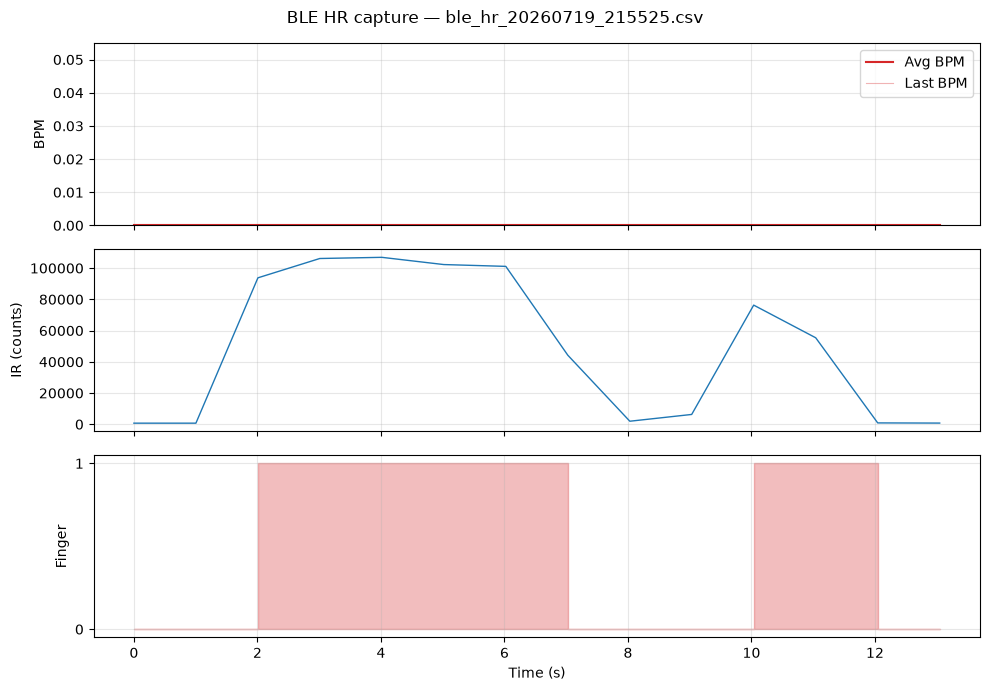

In [ ]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7))
fig.suptitle(f"BLE HR capture — {CSV.name}")

axes[0].plot(df["t_s"], df["avg_bpm"], color="C3", linewidth=1.5, label="Avg BPM")
axes[0].plot(df["t_s"], df["last_bpm"], color="C3", linewidth=0.8, alpha=0.35, label="Last BPM")
axes[0].set_ylabel("BPM")
axes[0].set_ylim(bottom=0)
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["t_s"], df["ir"], color="C0", linewidth=1.0)
axes[1].set_ylabel("IR (counts)")
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(df["t_s"], 0, df["finger"].astype(int), step="post", color="C3", alpha=0.3)
axes[2].set_ylabel("Finger")
axes[2].set_yticks([0, 1])
axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()